# Tarea práctica: Descubriendo patrones con K-Means

**Estudiante:** Josué Jiménez  
**Asignatura:** Software de habilidad lógico matemático  
**Tema:** Aprendizaje no supervisado — Agrupamiento con K-Means

---

## Objetivo

Aplicar el algoritmo **K-Means** para descubrir grupos (clusters) dentro de un conjunto de datos de
estudiantes e interpretar los resultados obtenidos.

## Contexto

Una institución educativa desea analizar el comportamiento académico de sus estudiantes a partir de
dos variables:

- **Horas de estudio por semana**
- **Promedio académico** (escala de 0 a 10)

El objetivo es descubrir, sin etiquetas previas, qué perfiles de estudiante existen dentro del curso.

## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

%matplotlib inline

# Semilla fija para que los resultados sean reproducibles
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (9, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Librerias importadas correctamente")
print("pandas:", pd.__version__, "| numpy:", np.__version__)

Librerias importadas correctamente
pandas: 3.0.5 | numpy: 2.4.6


## 2. Creación del conjunto de datos

Se construye un conjunto de **18 estudiantes** (el mínimo solicitado era 15) con su nombre, las horas
de estudio semanales y su promedio académico.

In [2]:
datos = {
    "Estudiante": [
        "Ana Torres", "Luis Perez", "Carla Ruiz", "Diego Salas", "Maria Lopez",
        "Fernando Silva", "Jorge Vega", "Sofia Cruz", "Andres Mora", "Paula Diaz",
        "Ricardo Nieto", "Camila Rojas", "Elena Castro", "Tomas Herrera",
        "Valeria Ponce", "Martin Aguirre", "Lucia Benitez", "Gabriela Ortiz"
    ],
    "Horas_Estudio": [22, 20, 24, 21, 23, 19, 12, 14, 13, 15, 11, 16, 5, 4, 6, 3, 7, 8],
    "Promedio":     [9.5, 9.2, 9.7, 9.0, 9.4, 8.9, 7.8, 8.0, 7.5, 8.2, 7.6, 8.4,
                     6.0, 5.5, 6.3, 5.2, 6.5, 6.8]
}

df = pd.DataFrame(datos)
df

,Estudiante,Horas_Estudio,Promedio
0,Ana Torres,22,9.5
1,Luis Perez,20,9.2
2,Carla Ruiz,24,9.7
3,Diego Salas,21,9.0
4,Maria Lopez,23,9.4
5,Fernando Silva,19,8.9
6,Jorge Vega,12,7.8
7,Sofia Cruz,14,8.0
8,Andres Mora,13,7.5
9,Paula Diaz,15,8.2


In [3]:
# Exploracion rapida del DataFrame
print("Dimensiones del DataFrame:", df.shape)
print()
print(df.info())
print()
print(df[["Horas_Estudio", "Promedio"]].describe())

Dimensiones del DataFrame: (18, 3)

<class 'pandas.DataFrame'>
RangeIndex: 18 entries, 0 to 17
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Estudiante     18 non-null     str    
 1   Horas_Estudio  18 non-null     int64  
 2   Promedio       18 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 564.0 bytes
None

       Horas_Estudio   Promedio
count       18.00000  18.000000
mean        13.50000   7.750000
std          6.94728   1.425503
min          3.00000   5.200000
25%          7.25000   6.575000
50%         13.50000   7.900000
75%         19.75000   8.975000
max         24.00000   9.700000


## 3. Gráfico de dispersión **antes** de aplicar K-Means

Antes de agrupar, observamos los datos "en crudo": todos los puntos tienen el mismo color porque
todavía no sabemos a qué grupo pertenece cada estudiante.

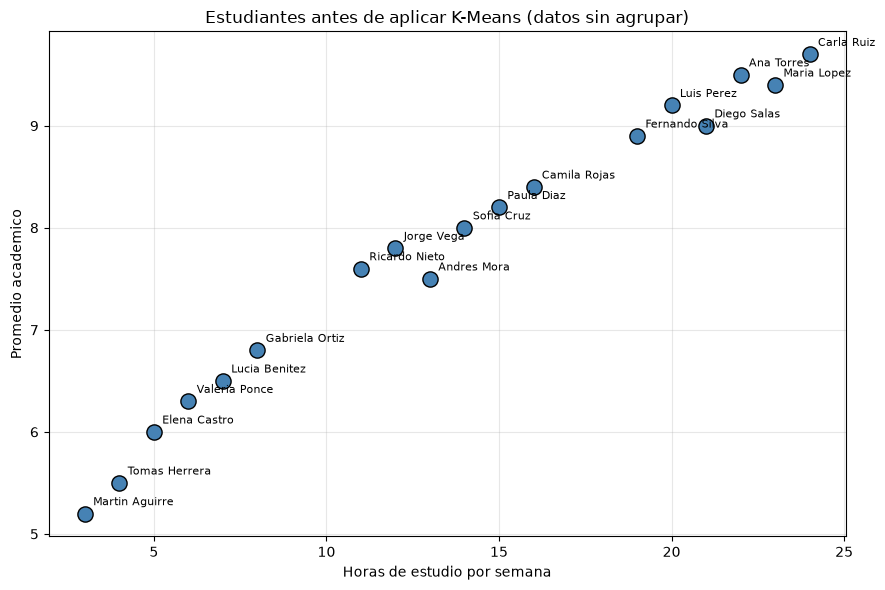

In [4]:
plt.figure()
plt.scatter(df["Horas_Estudio"], df["Promedio"],
            s=120, c="steelblue", edgecolors="black", zorder=3)

for _, fila in df.iterrows():
    plt.annotate(fila["Estudiante"],
                 (fila["Horas_Estudio"], fila["Promedio"]),
                 textcoords="offset points", xytext=(6, 6), fontsize=8)

plt.title("Estudiantes antes de aplicar K-Means (datos sin agrupar)")
plt.xlabel("Horas de estudio por semana")
plt.ylabel("Promedio academico")
plt.tight_layout()
plt.show()

**Observación:** a simple vista ya se intuyen tres nubes de puntos: un grupo abajo a la izquierda
(pocas horas y promedio bajo), un grupo intermedio y un grupo arriba a la derecha (muchas horas y
promedio alto). K-Means debería encontrar justamente esa estructura.

## 4. Aplicación del algoritmo K-Means con K = 3

In [5]:
# Variables que usara el algoritmo (K-Means solo trabaja con numeros)
X = df[["Horas_Estudio", "Promedio"]].values

# Creamos y entrenamos el modelo con 3 grupos
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(X)

etiquetas = kmeans.labels_
centroides = kmeans.cluster_centers_

print("Etiquetas asignadas a cada estudiante:")
print(etiquetas)
print()
print("Inercia del modelo (suma de distancias al cuadrado):", round(kmeans.inertia_, 3))

Etiquetas asignadas a cada estudiante:
[2 2 2 2 2 2 1 1 1 1 1 1 0 0 0 0 0 0]

Inercia del modelo (suma de distancias al cuadrado): 55.432


## 5. Agregar el grupo asignado al DataFrame

In [6]:
df["Grupo"] = etiquetas
df

,Estudiante,Horas_Estudio,Promedio,Grupo
0,Ana Torres,22,9.5,2
1,Luis Perez,20,9.2,2
2,Carla Ruiz,24,9.7,2
3,Diego Salas,21,9.0,2
4,Maria Lopez,23,9.4,2
5,Fernando Silva,19,8.9,2
6,Jorge Vega,12,7.8,1
7,Sofia Cruz,14,8.0,1
8,Andres Mora,13,7.5,1
9,Paula Diaz,15,8.2,1


In [7]:
# Cuantos estudiantes quedaron en cada grupo
df["Grupo"].value_counts().sort_index()

Grupo
0    6
1    6
2    6
Name: count, dtype: int64

## 6. Gráfico con estudiantes, grupos y centroides

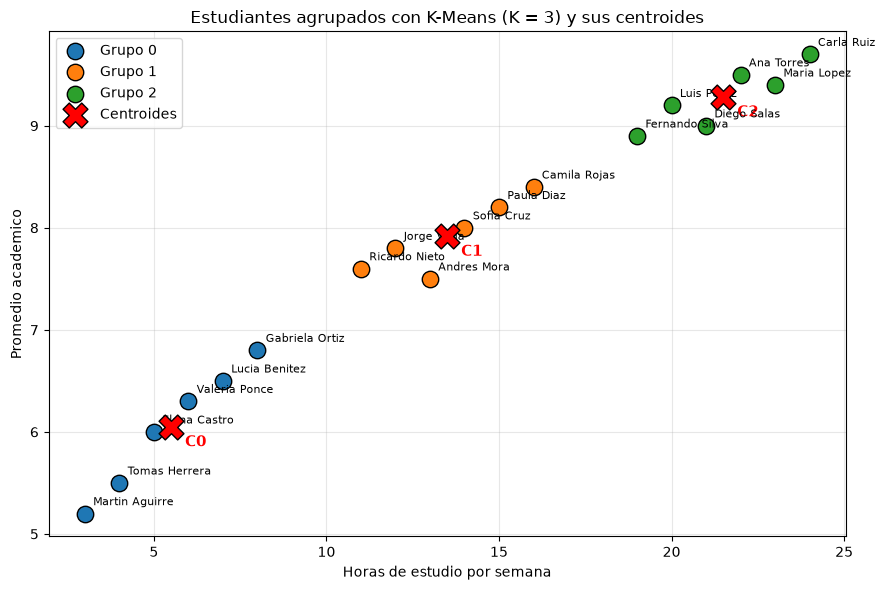

In [8]:
colores = ["tab:blue", "tab:orange", "tab:green"]

plt.figure()
for g in sorted(df["Grupo"].unique()):
    sub = df[df["Grupo"] == g]
    plt.scatter(sub["Horas_Estudio"], sub["Promedio"],
                s=140, c=colores[g], edgecolors="black",
                label=f"Grupo {g}", zorder=3)

# Centroides
plt.scatter(centroides[:, 0], centroides[:, 1],
            s=320, c="red", marker="X", edgecolors="black",
            label="Centroides", zorder=4)

for i, (cx, cy) in enumerate(centroides):
    plt.annotate(f"C{i}", (cx, cy), textcoords="offset points",
                 xytext=(10, -14), fontsize=11, fontweight="bold", color="red")

for _, fila in df.iterrows():
    plt.annotate(fila["Estudiante"],
                 (fila["Horas_Estudio"], fila["Promedio"]),
                 textcoords="offset points", xytext=(6, 6), fontsize=8)

plt.title("Estudiantes agrupados con K-Means (K = 3) y sus centroides")
plt.xlabel("Horas de estudio por semana")
plt.ylabel("Promedio academico")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Valores de los 3 centroides

In [9]:
tabla_centroides = pd.DataFrame(
    centroides,
    columns=["Horas_Estudio (centroide)", "Promedio (centroide)"]
).round(2)
tabla_centroides.index.name = "Grupo"
tabla_centroides

,Horas_Estudio (centroide),Promedio (centroide)
Grupo,,
0,5.5,6.05
1,13.5,7.92
2,21.5,9.28


In [10]:
for i, (h, p) in enumerate(centroides):
    print(f"Centroide del grupo {i}: {h:.2f} horas de estudio  |  promedio {p:.2f}")

Centroide del grupo 0: 5.50 horas de estudio  |  promedio 6.05
Centroide del grupo 1: 13.50 horas de estudio  |  promedio 7.92
Centroide del grupo 2: 21.50 horas de estudio  |  promedio 9.28


## 8. Características de cada grupo y nombre descriptivo

Para nombrar los grupos no usamos el número que el algoritmo asignó (ese número es arbitrario), sino
que ordenamos los centroides de menor a mayor cantidad de horas de estudio y les damos un nombre
según su perfil.

In [11]:
resumen = (df.groupby("Grupo")
             .agg(Cantidad=("Estudiante", "count"),
                  Horas_promedio=("Horas_Estudio", "mean"),
                  Promedio_medio=("Promedio", "mean"),
                  Horas_min=("Horas_Estudio", "min"),
                  Horas_max=("Horas_Estudio", "max"),
                  Nota_min=("Promedio", "min"),
                  Nota_max=("Promedio", "max"))
             .round(2))
resumen

,Cantidad,Horas_promedio,Promedio_medio,Horas_min,Horas_max,Nota_min,Nota_max
Grupo,,,,,,,
0,6,5.5,6.05,3,8,5.2,6.8
1,6,13.5,7.92,11,16,7.5,8.4
2,6,21.5,9.28,19,24,8.9,9.7


In [12]:
# Ordenamos los grupos por las horas de estudio de su centroide
orden = np.argsort(centroides[:, 0])   # grupo con menos horas -> grupo con mas horas
nombres = ["Bajo rendimiento / poco estudio",
           "Rendimiento medio / estudio moderado",
           "Alto rendimiento / mucho estudio"]

nombre_grupo = {int(g): nombres[pos] for pos, g in enumerate(orden)}

for g, nombre in sorted(nombre_grupo.items()):
    h, p = centroides[g]
    print(f"Grupo {g} -> {nombre}")
    print(f"   Centroide: {h:.2f} horas | promedio {p:.2f}")
    print(f"   Estudiantes: {', '.join(df[df['Grupo'] == g]['Estudiante'])}")
    print()

Grupo 0 -> Bajo rendimiento / poco estudio
   Centroide: 5.50 horas | promedio 6.05
   Estudiantes: Elena Castro, Tomas Herrera, Valeria Ponce, Martin Aguirre, Lucia Benitez, Gabriela Ortiz

Grupo 1 -> Rendimiento medio / estudio moderado
   Centroide: 13.50 horas | promedio 7.92
   Estudiantes: Jorge Vega, Sofia Cruz, Andres Mora, Paula Diaz, Ricardo Nieto, Camila Rojas

Grupo 2 -> Alto rendimiento / mucho estudio
   Centroide: 21.50 horas | promedio 9.28
   Estudiantes: Ana Torres, Luis Perez, Carla Ruiz, Diego Salas, Maria Lopez, Fernando Silva



In [13]:
df["Nombre_del_Grupo"] = df["Grupo"].map(nombre_grupo)
df.sort_values(["Grupo", "Horas_Estudio"]).reset_index(drop=True)

,Estudiante,Horas_Estudio,Promedio,Grupo,Nombre_del_Grupo
0,Martin Aguirre,3,5.2,0,Bajo rendimiento / poco estudio
1,Tomas Herrera,4,5.5,0,Bajo rendimiento / poco estudio
2,Elena Castro,5,6.0,0,Bajo rendimiento / poco estudio
3,Valeria Ponce,6,6.3,0,Bajo rendimiento / poco estudio
4,Lucia Benitez,7,6.5,0,Bajo rendimiento / poco estudio
5,Gabriela Ortiz,8,6.8,0,Bajo rendimiento / poco estudio
6,Ricardo Nieto,11,7.6,1,Rendimiento medio / estudio moderado
7,Jorge Vega,12,7.8,1,Rendimiento medio / estudio moderado
8,Andres Mora,13,7.5,1,Rendimiento medio / estudio moderado
9,Sofia Cruz,14,8.0,1,Rendimiento medio / estudio moderado


### Interpretación de los grupos

| Perfil | Descripción |
|---|---|
| **Bajo rendimiento / poco estudio** | Estudiantes con menos de 10 horas semanales y promedios cercanos a 6. Son quienes más necesitan acompañamiento y refuerzo académico. |
| **Rendimiento medio / estudio moderado** | Estudiantes que dedican entre 11 y 16 horas semanales y obtienen promedios entre 7.5 y 8.5. Con un poco más de dedicación podrían pasar al grupo alto. |
| **Alto rendimiento / mucho estudio** | Estudiantes con 19 horas o más de estudio y promedios superiores a 8.9. Son candidatos a tutorías entre pares, becas o proyectos de investigación. |

Se observa una **relación directa** entre las horas de estudio y el promedio: a mayor dedicación,
mayor rendimiento académico.

## 9. Predicción para un estudiante nuevo

Creamos un estudiante que **no** forma parte de los datos originales y usamos el modelo ya entrenado
para determinar a qué grupo pertenece.

In [14]:
nuevo_nombre = "Mateo Andrade"
nuevo_horas = 18
nuevo_promedio = 8.7

nuevo_estudiante = np.array([[nuevo_horas, nuevo_promedio]])
grupo_nuevo = int(kmeans.predict(nuevo_estudiante)[0])

print(f"Estudiante nuevo: {nuevo_nombre}")
print(f"   Horas de estudio: {nuevo_horas}")
print(f"   Promedio: {nuevo_promedio}")
print()
print(f"Grupo asignado por el modelo: {grupo_nuevo}  ->  {nombre_grupo[grupo_nuevo]}")

Estudiante nuevo: Mateo Andrade
   Horas de estudio: 18
   Promedio: 8.7

Grupo asignado por el modelo: 2  ->  Alto rendimiento / mucho estudio


In [15]:
# Distancia del nuevo estudiante a cada centroide (asi decide K-Means)
distancias = np.linalg.norm(centroides - nuevo_estudiante, axis=1)

tabla_dist = pd.DataFrame({
    "Grupo": range(len(centroides)),
    "Nombre del grupo": [nombre_grupo[i] for i in range(len(centroides))],
    "Centroide (horas)": centroides[:, 0].round(2),
    "Centroide (promedio)": centroides[:, 1].round(2),
    "Distancia al nuevo estudiante": distancias.round(3)
}).sort_values("Distancia al nuevo estudiante").reset_index(drop=True)

tabla_dist

,Grupo,Nombre del grupo,Centroide (horas),Centroide (promedio),Distancia al nuevo estudiante
0,2,Alto rendimiento / mucho estudio,21.5,9.28,3.548
1,1,Rendimiento medio / estudio moderado,13.5,7.92,4.568
2,0,Bajo rendimiento / poco estudio,5.5,6.05,12.778


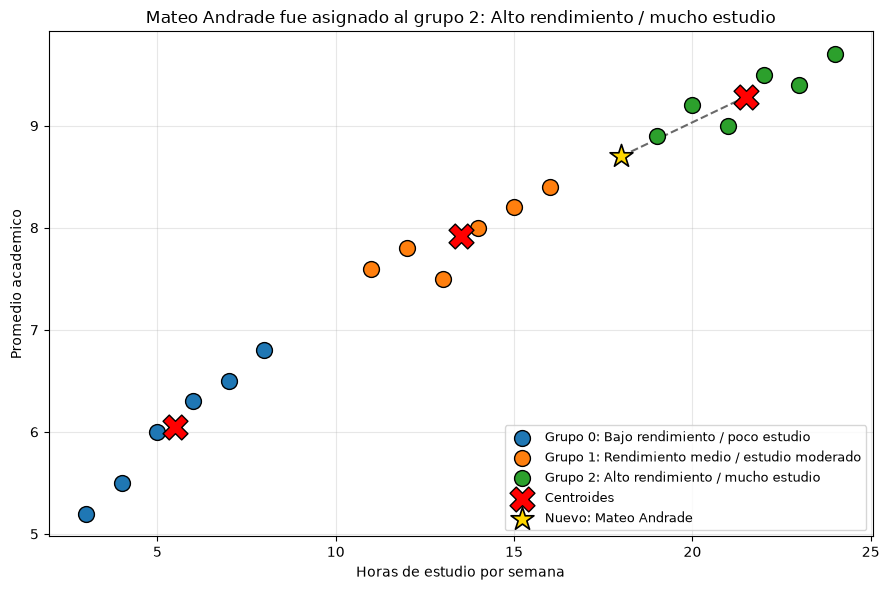

In [16]:
plt.figure()
for g in sorted(df["Grupo"].unique()):
    sub = df[df["Grupo"] == g]
    plt.scatter(sub["Horas_Estudio"], sub["Promedio"],
                s=130, c=colores[g], edgecolors="black",
                label=f"Grupo {g}: {nombre_grupo[g]}", zorder=3)

plt.scatter(centroides[:, 0], centroides[:, 1],
            s=320, c="red", marker="X", edgecolors="black",
            label="Centroides", zorder=4)

# Nuevo estudiante
plt.scatter(nuevo_horas, nuevo_promedio, s=300, c="gold", marker="*",
            edgecolors="black", linewidths=1.2, label=f"Nuevo: {nuevo_nombre}", zorder=5)

# Linea hacia el centroide mas cercano
cx, cy = centroides[grupo_nuevo]
plt.plot([nuevo_horas, cx], [nuevo_promedio, cy],
         "--", c="dimgray", linewidth=1.5, zorder=2)

plt.title(f"{nuevo_nombre} fue asignado al grupo {grupo_nuevo}: {nombre_grupo[grupo_nuevo]}")
plt.xlabel("Horas de estudio por semana")
plt.ylabel("Promedio academico")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

In [17]:
# Agregamos el nuevo estudiante al DataFrame para verlo junto a sus companeros de grupo
df_completo = pd.concat([
    df,
    pd.DataFrame([{
        "Estudiante": nuevo_nombre,
        "Horas_Estudio": nuevo_horas,
        "Promedio": nuevo_promedio,
        "Grupo": grupo_nuevo,
        "Nombre_del_Grupo": nombre_grupo[grupo_nuevo]
    }])
], ignore_index=True)

df_completo.tail(6)

,Estudiante,Horas_Estudio,Promedio,Grupo,Nombre_del_Grupo
13,Tomas Herrera,4,5.5,0,Bajo rendimiento / poco estudio
14,Valeria Ponce,6,6.3,0,Bajo rendimiento / poco estudio
15,Martin Aguirre,3,5.2,0,Bajo rendimiento / poco estudio
16,Lucia Benitez,7,6.5,0,Bajo rendimiento / poco estudio
17,Gabriela Ortiz,8,6.8,0,Bajo rendimiento / poco estudio
18,Mateo Andrade,18,8.7,2,Alto rendimiento / mucho estudio


### 10. ¿Por qué el nuevo estudiante fue asignado a ese grupo?

Porque **K-Means mide la distancia euclidiana entre el nuevo punto y cada uno de los tres
centroides, y lo asigna al centroide más cercano**.

Mateo Andrade estudia 18 horas semanales y tiene un promedio de 8.7. En la tabla de distancias se ve
que el centroide del grupo de **alto rendimiento** es el que queda más cerca de él: su perfil se
parece mucho más al de Ana, Luis o Fernando (muchas horas de estudio y notas altas) que al del grupo
intermedio o al del grupo de bajo rendimiento. Por eso el modelo lo ubica en ese grupo, aunque nunca
haya visto ese dato durante el entrenamiento.

---

## Preguntas de análisis

### a. ¿Qué representa un centroide en K-Means?

El centroide es el **punto promedio de todos los estudiantes que pertenecen a un grupo**: sus
coordenadas son la media de las horas de estudio y la media del promedio académico de ese grupo. Es
como el "estudiante típico" o representante del grupo; no necesariamente existe en los datos reales,
pero resume el comportamiento del conjunto y sirve como referencia para medir distancias.

### b. ¿Qué significan los números 0, 1 y 2 asignados por el algoritmo?

Son simplemente **etiquetas o nombres de grupo**, no calificaciones ni un orden de mejor a peor. El
0 no es "peor" que el 2. Si volviéramos a ejecutar el algoritmo con otra semilla, los mismos
estudiantes podrían quedar juntos pero con números diferentes. Por eso en este trabajo interpretamos
cada número mirando su centroide y le pusimos un nombre descriptivo.

### c. ¿Cómo decide K-Means a qué grupo pertenece un nuevo estudiante?

1. Toma los valores del nuevo estudiante (horas de estudio y promedio).
2. Calcula la **distancia euclidiana** entre ese punto y cada uno de los K centroides ya calculados.
3. Lo asigna al grupo cuyo **centroide esté a menor distancia**.

No usa etiquetas previas ni conoce la "respuesta correcta": solo compara qué tan parecido es el
nuevo dato a cada representante de grupo.

### d. ¿Qué utilidad podría tener esta segmentación para una institución educativa?

- **Detectar a tiempo** a los estudiantes en riesgo académico y ofrecerles tutorías o refuerzo.
- **Diseñar estrategias diferenciadas** para cada perfil en lugar de una única estrategia para todos.
- **Formar tutorías entre pares**, uniendo estudiantes de alto rendimiento con los de bajo rendimiento.
- **Identificar candidatos** a becas, semilleros de investigación o representación institucional.
- **Evaluar el impacto de los hábitos de estudio**, al ver la relación entre horas dedicadas y notas.
- **Distribuir mejor los recursos** (docentes de apoyo, talleres, horarios de biblioteca).

### e. ¿Qué sucedería si cambiamos `n_clusters=3` por `n_clusters=2` o `n_clusters=4`?

- Con **K = 2** el algoritmo hace una división más gruesa: el grupo intermedio deja de existir y sus
  integrantes se reparten entre los dos extremos, quedando algo parecido a "estudiantes dedicados"
  (9 estudiantes) vs. "estudiantes con poca dedicación" (9 estudiantes). Se pierde el matiz del
  grupo medio.
- Con **K = 4** el algoritmo parte uno de los grupos en dos subgrupos más finos (en nuestros datos
  divide el grupo de bajo rendimiento en uno de ~4 horas y otro de ~7 horas, con 3 estudiantes cada
  uno). Se gana detalle, pero los grupos quedan más pequeños y las diferencias entre ellos son menos
  claras.

En la siguiente sección lo comprobamos ejecutando el algoritmo con esos valores.

---

## Reto adicional ⭐ — Comparación entre K = 2, K = 3 y K = 4

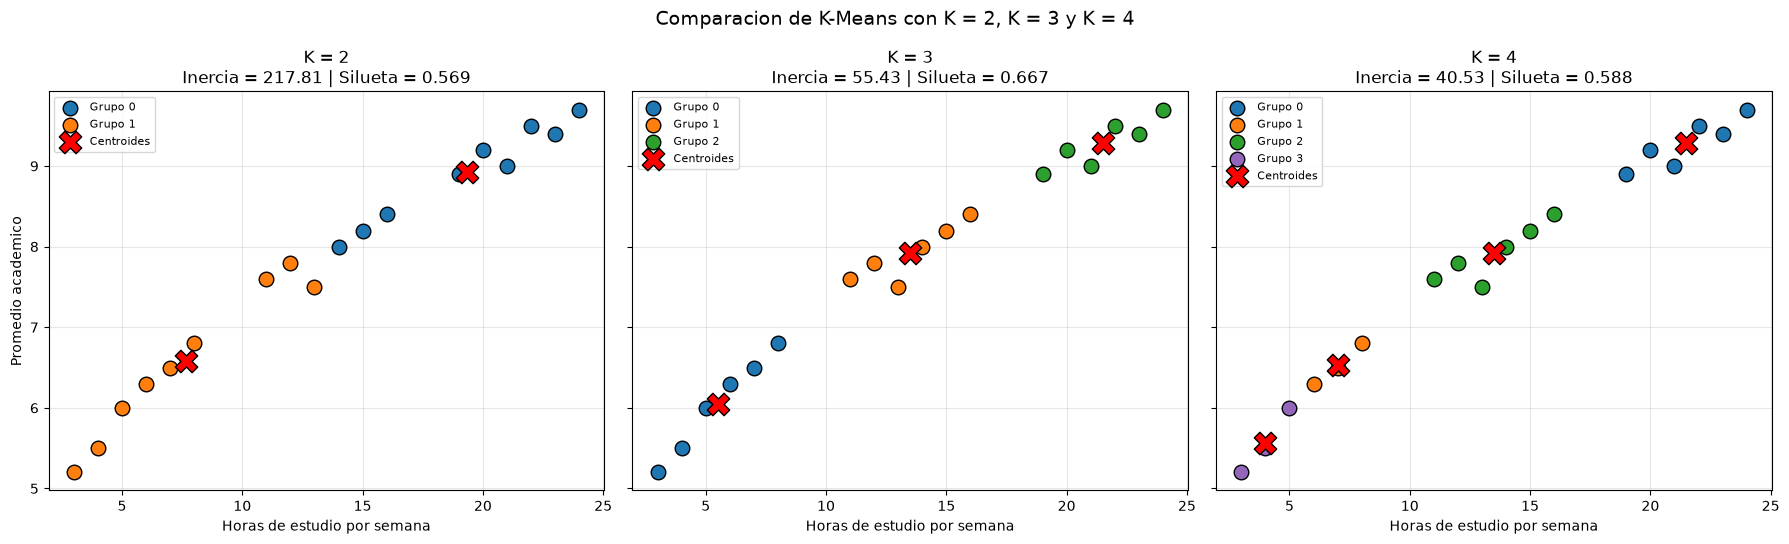

In [18]:
resultados = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)
paleta = ["tab:blue", "tab:orange", "tab:green", "tab:purple"]

for ax, k in zip(axes, [2, 3, 4]):
    modelo = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lab = modelo.fit_predict(X)
    cen = modelo.cluster_centers_

    sil = silhouette_score(X, lab)
    resultados[k] = {"modelo": modelo, "labels": lab,
                     "inercia": modelo.inertia_, "silueta": sil}

    df[f"Grupo_K{k}"] = lab

    for g in range(k):
        sub = X[lab == g]
        ax.scatter(sub[:, 0], sub[:, 1], s=110, c=paleta[g],
                   edgecolors="black", label=f"Grupo {g}", zorder=3)

    ax.scatter(cen[:, 0], cen[:, 1], s=260, c="red", marker="X",
               edgecolors="black", label="Centroides", zorder=4)
    ax.set_title(f"K = {k}\nInercia = {modelo.inertia_:.2f} | Silueta = {sil:.3f}")
    ax.set_xlabel("Horas de estudio por semana")
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylabel("Promedio academico")
plt.suptitle("Comparacion de K-Means con K = 2, K = 3 y K = 4", fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
comparacion = pd.DataFrame({
    "K": list(resultados.keys()),
    "Inercia (menor = grupos mas compactos)": [round(v["inercia"], 2) for v in resultados.values()],
    "Coeficiente de silueta (mayor = mejor separacion)": [round(v["silueta"], 3) for v in resultados.values()]
})
comparacion

,K,Inercia (menor = grupos mas compactos),Coeficiente de silueta (mayor = mejor separacion)
0,2,217.81,0.569
1,3,55.43,0.667
2,4,40.53,0.588


In [20]:
# Centroides obtenidos con cada valor de K
for k, v in resultados.items():
    print(f"--- K = {k} ---")
    cen = v["modelo"].cluster_centers_
    for i, (h, p) in enumerate(cen):
        n = int((v["labels"] == i).sum())
        print(f"  Grupo {i}: centroide ({h:.2f} horas, promedio {p:.2f})  |  {n} estudiantes")
    print()

--- K = 2 ---
  Grupo 0: centroide (19.33 horas, promedio 8.92)  |  9 estudiantes
  Grupo 1: centroide (7.67 horas, promedio 6.58)  |  9 estudiantes

--- K = 3 ---
  Grupo 0: centroide (5.50 horas, promedio 6.05)  |  6 estudiantes
  Grupo 1: centroide (13.50 horas, promedio 7.92)  |  6 estudiantes
  Grupo 2: centroide (21.50 horas, promedio 9.28)  |  6 estudiantes

--- K = 4 ---
  Grupo 0: centroide (21.50 horas, promedio 9.28)  |  6 estudiantes
  Grupo 1: centroide (7.00 horas, promedio 6.53)  |  3 estudiantes
  Grupo 2: centroide (13.50 horas, promedio 7.92)  |  6 estudiantes
  Grupo 3: centroide (4.00 horas, promedio 5.57)  |  3 estudiantes



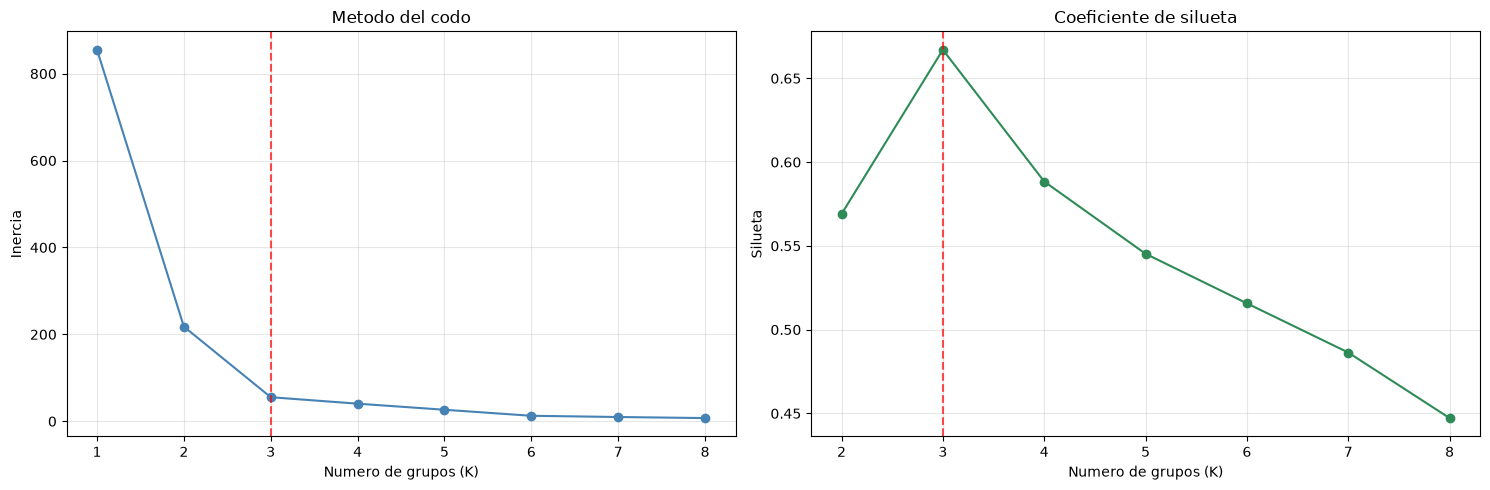

K = 1: inercia =   855.04 | silueta = nan
K = 2: inercia =   217.81 | silueta = 0.569
K = 3: inercia =    55.43 | silueta = 0.667
K = 4: inercia =    40.53 | silueta = 0.588
K = 5: inercia =    26.55 | silueta = 0.545
K = 6: inercia =    12.67 | silueta = 0.516
K = 7: inercia =     9.86 | silueta = 0.486
K = 8: inercia =     7.39 | silueta = 0.447


In [21]:
# Metodo del codo: inercia para K = 1 hasta 8
ks = range(1, 9)
inercias = []
siluetas = []

for k in ks:
    m = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X)
    inercias.append(m.inertia_)
    siluetas.append(silhouette_score(X, m.labels_) if k > 1 else np.nan)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(list(ks), inercias, "o-", color="steelblue")
ax1.axvline(3, color="red", linestyle="--", alpha=0.7)
ax1.set_title("Metodo del codo")
ax1.set_xlabel("Numero de grupos (K)")
ax1.set_ylabel("Inercia")
ax1.grid(alpha=0.3)

ax2.plot(list(ks), siluetas, "o-", color="seagreen")
ax2.axvline(3, color="red", linestyle="--", alpha=0.7)
ax2.set_title("Coeficiente de silueta")
ax2.set_xlabel("Numero de grupos (K)")
ax2.set_ylabel("Silueta")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

for k, inn, sil in zip(ks, inercias, siluetas):
    print(f"K = {k}: inercia = {inn:8.2f} | silueta = {sil if k == 1 else round(sil, 3)}")

In [22]:
# Como se reparten los estudiantes con cada K
df[["Estudiante", "Horas_Estudio", "Promedio", "Grupo_K2", "Grupo_K3", "Grupo_K4"]]

,Estudiante,Horas_Estudio,Promedio,Grupo_K2,Grupo_K3,Grupo_K4
0,Ana Torres,22,9.5,0,2,0
1,Luis Perez,20,9.2,0,2,0
2,Carla Ruiz,24,9.7,0,2,0
3,Diego Salas,21,9.0,0,2,0
4,Maria Lopez,23,9.4,0,2,0
5,Fernando Silva,19,8.9,0,2,0
6,Jorge Vega,12,7.8,1,1,2
7,Sofia Cruz,14,8.0,0,1,2
8,Andres Mora,13,7.5,1,1,2
9,Paula Diaz,15,8.2,0,1,2


### ¿Cuál valor de K representa mejor los datos y por qué?

**K = 3 es el que mejor representa estos datos.** Razones:

1. **Método del codo:** la inercia baja mucho al pasar de K = 1 a K = 3, y a partir de K = 3 la
   mejora se vuelve muy pequeña. Ese "codo" en la gráfica indica que agregar más grupos ya casi no
   aporta compacidad.
2. **Coeficiente de silueta:** K = 3 obtiene el valor más alto de la comparación, es decir, los
   grupos quedan bien separados entre sí y cohesionados por dentro.
3. **Sentido pedagógico:** los tres grupos coinciden con una lectura natural del curso —
   *bajo rendimiento*, *rendimiento medio* y *alto rendimiento* — y esa es una segmentación sobre la
   que la institución puede actuar directamente.

Con **K = 2** (silueta 0.569) la separación es demasiado gruesa: desaparece el grupo intermedio —
justamente el más interesante para intervenir — y sus estudiantes se reparten entre los dos
extremos. Con **K = 4** (silueta 0.588) se parte el grupo de bajo rendimiento en dos subgrupos muy
parecidos entre sí, de apenas 3 estudiantes cada uno, lo que hace más difícil interpretar y actuar
sobre los resultados sin ganar información realmente nueva.

> **Nota técnica:** en este ejercicio se trabajó con las variables en su escala original, tal como se
> vio en clase. Cuando las variables tienen rangos muy distintos (aquí las horas van de 3 a 24 y el
> promedio de 5.2 a 9.7), la variable de mayor rango pesa más en el cálculo de la distancia. Una
> mejora posible sería normalizar los datos con `StandardScaler` antes de aplicar K-Means.

---

## Conclusiones

1. K-Means logró descubrir, **sin ninguna etiqueta previa**, tres perfiles claros de estudiante
   dentro del curso.
2. Los centroides resumen a cada grupo y funcionan como "estudiante representativo" del perfil.
3. Existe una relación directa entre las **horas de estudio semanales** y el **promedio académico**.
4. El modelo entrenado permite clasificar **estudiantes nuevos** de forma inmediata, calculando la
   distancia a cada centroide.
5. La comparación entre K = 2, K = 3 y K = 4, junto con el método del codo y el coeficiente de
   silueta, confirma que **K = 3** es la mejor elección para este conjunto de datos.
6. Para la institución, esta segmentación es una herramienta concreta para **detectar riesgo
   académico a tiempo** y diseñar apoyos diferenciados para cada perfil.